In [1]:
# 실습 준비 - 패키지 설치·폰트·GPU 확인·Chronos-2 내려받기
# [heavy]
#  Colab 이거나 내 컴퓨터에 두 패키지가 없으면 chronos-forecasting 2.3.1 · holidays 0.103 을 설치합니다.
#  교안의 수를 계산한 버전에 맞춰 고정합니다.
#  numpy · pandas · pyarrow · torch · matplotlib 은 Colab 기본 버전을 그대로 씁니다.
import os, sys, time, subprocess, importlib.util
IN_COLAB = "google.colab" in sys.modules
_missing = [m for m in ("chronos", "holidays") if importlib.util.find_spec(m) is None]
if IN_COLAB or _missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "chronos-forecasting==2.3.1", "holidays==0.103"], check=True)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings; warnings.filterwarnings("ignore")

# 한글 폰트 — Colab 이면 나눔고딕을 설치한 뒤 그 ttf 를 폰트 목록에 **직접** 등록한다.
#  설치는 디스크에 파일만 만든다. 이미 떠 있는 폰트 목록은 그 사실을 모르므로 addfont 로
#  넣어 줘야 이름이 보인다(넣지 않으면 DejaVu Sans 로 밀려 한글이 전부 □ 로 나온다).
import glob, shutil
if IN_COLAB and shutil.which("apt-get"):
    subprocess.run(["apt-get", "-y", "-qq", "install", "fonts-nanum"], check=False)
for _p in glob.glob("/usr/share/fonts/truetype/nanum/Nanum*.ttf"):   # 설치 여부와 무관하게 한 번
    try: fm.fontManager.addfont(_p)
    except Exception: pass
try: fm._get_font.cache_clear()
except Exception: pass
installed = {f.name for f in fm.fontManager.ttflist}
FONT = next((n for n in ["Pretendard", "Apple SD Gothic Neo", "NanumGothic"] if n in installed), "DejaVu Sans")
plt.rcParams["font.family"] = FONT
plt.rcParams["axes.unicode_minus"] = FONT in {"Pretendard", "DejaVu Sans"}   # 나머지 폰트에는 U+2212 가 없다
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}   # 그림마다 폭이 깎이지 않게
plt.rcParams["figure.dpi"] = plt.rcParams["savefig.dpi"] = 150       # 폭 FIG_W x 150dpi = 1500px 고정
plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({"font.size": 11, "axes.titlesize": 15, "axes.labelsize": 12,
                     "legend.fontsize": 11, "figure.titlesize": 17, "font.weight": "regular",
                     "text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
                     "axes.edgecolor": "#757575", "xtick.color": "#757575", "ytick.color": "#757575",
                     "xtick.labelcolor": "black", "ytick.labelcolor": "black",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})

# 오늘 그림 전체가 함께 쓰는 색 — 기준선=남색, 관측=파랑, 강조=하늘색, 문맥=회색
COL = {"남색": "#051C2C", "파랑": "#2251FF", "하늘색": "#00A9F4",
       "회색": "#757575", "연회색": "#B3B3B3"}
FIG_W = 10.0     # 캔버스 폭은 오늘 그림 모두 이 값으로 고정하고 높이만 그림마다 조절한다
FIGW = FIG_W      # 도우미가 밑줄을 빼고 FIGW 로 옮겨 적는 일이 있어 같은 값을 하나 더 둔다

try:
    import holidays
    _hol_ver = holidays.__version__
except ImportError:
    _hol_ver = "없음"
print("사용 폰트:", FONT, "| 색 팔레트 준비 완료 | holidays", _hol_ver)

# GPU 확인 — Chronos-2 예측은 여기서 정한 DEVICE 에서 실행됩니다
#  정밀도는 32비트 실수(fp32)로 두고, A100·L4 의 TF32 행렬곱을 꺼 GPU 종류에 따른 차이를 줄입니다.
#  오늘 쓰는 Chronos-2 분위수는 Colab T4 와 CPU 에서 원점별 포함률이 같게 나왔습니다.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
if DEVICE == "cuda":
    _gpu = torch.cuda.get_device_properties(0)
    print(f"DEVICE : cuda | GPU {torch.cuda.get_device_name(0)} | 메모리 {_gpu.total_memory / 1e9:.1f} GB"
          f" | torch {torch.__version__}")
else:
    print(f"DEVICE : cpu | GPU 없음 | torch {torch.__version__}")
    print("GPU 가 연결되지 않았습니다. 메뉴 런타임 → 런타임 유형 변경 → GPU 를 고른 뒤 맨 위 셀부터 다시 실행합니다.")
    print("그대로 두면 같은 코드가 CPU 에서 실행되고, 「오늘의 준비」 셀이 약 100초 걸립니다.")

# Chronos-2 가중치(약 480MB)를 여기서 한 번 내려받아 둡니다. 「오늘의 준비」 셀과 미션 준비 셀은 이 사본을 읽습니다.
#  내려받기가 끊기면 10초 쉬고 다시 시도하며, 세 번까지 합니다.
from huggingface_hub import snapshot_download
CHRONOS_ID = "amazon/chronos-2"
for _try in range(1, 4):
    try:
        snapshot_download(CHRONOS_ID, allow_patterns=["config.json", "model.safetensors"])
        print(f"Chronos-2 가중치 준비 완료 : {CHRONOS_ID} ({_try}번째 시도)")
        break
    except Exception as _e:
        print(f"Chronos-2 내려받기 {_try}번째 실패 : {type(_e).__name__}")
        if _try < 3:
            time.sleep(10)
else:   # 받지 못한 채 넘어가면 뒤 셀의 from_pretrained 가 내려받기 오류로 멈춘다. 여기서 멈춘다
    raise RuntimeError("Chronos-2 가중치를 세 번 모두 받지 못했습니다. LMS 면 이 셀을 다시 실행하고, 그래도 같으면"
                       " 강사에게 알립니다. Colab 이면 메뉴 런타임 → 런타임 다시 시작을 누른 뒤 이 셀부터 다시 실행합니다")

사용 폰트: DejaVu Sans | 색 팔레트 준비 완료 | holidays 0.103
DEVICE : cpu | GPU 없음 | torch 2.14.1+cpu
GPU 가 연결되지 않았습니다. 메뉴 런타임 → 런타임 유형 변경 → GPU 를 고른 뒤 맨 위 셀부터 다시 실행합니다.
그대로 두면 같은 코드가 CPU 에서 실행되고, 「오늘의 준비」 셀이 약 100초 걸립니다.


Fetching 2 files: 100%|██████████| 2/2 [00:00<00:00, 397.13it/s]

Chronos-2 가중치 준비 완료 : amazon/chronos-2 (1번째 시도)


In [2]:
font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams["axes.unicode_minus"] = False

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 290.51it/s]


표 1 · 채점 7일의 평일 공휴일 (원점 5개)
  2025-08-13 · 공휴일 있는 주 : 08-15(금)
  2025-10-01 · 공휴일 있는 주 : 10-03(금) · 10-06(월) · 10-07(화)
  2025-12-10 · 공휴일 없는 주 : 없음
  2026-02-11 · 공휴일 있는 주 : 02-16(월) · 02-17(화)
  2026-06-24 · 공휴일 없는 주 : 없음
  주말 공휴일 2025-10-05(일, 추석 연휴)는 평일 공휴일로 세지 않습니다

표 2 · 강남역 원점 2026-06-24 Chronos-2 + 공휴일 분위수 아홉 열과 실제 (명)
              0.1    0.2    0.3    0.4    0.5    0.6    0.7    0.8    0.9     실제
2026-06-24  88811  89811  90461  91004  91534  91997  92588  93242  94206  94303
2026-06-25  89540  90667  91404  92025  92613  93155  93662  94262  95204  94077
2026-06-26  93593  94763  95428  95971  96586  97146  97839  98735  99793  98456


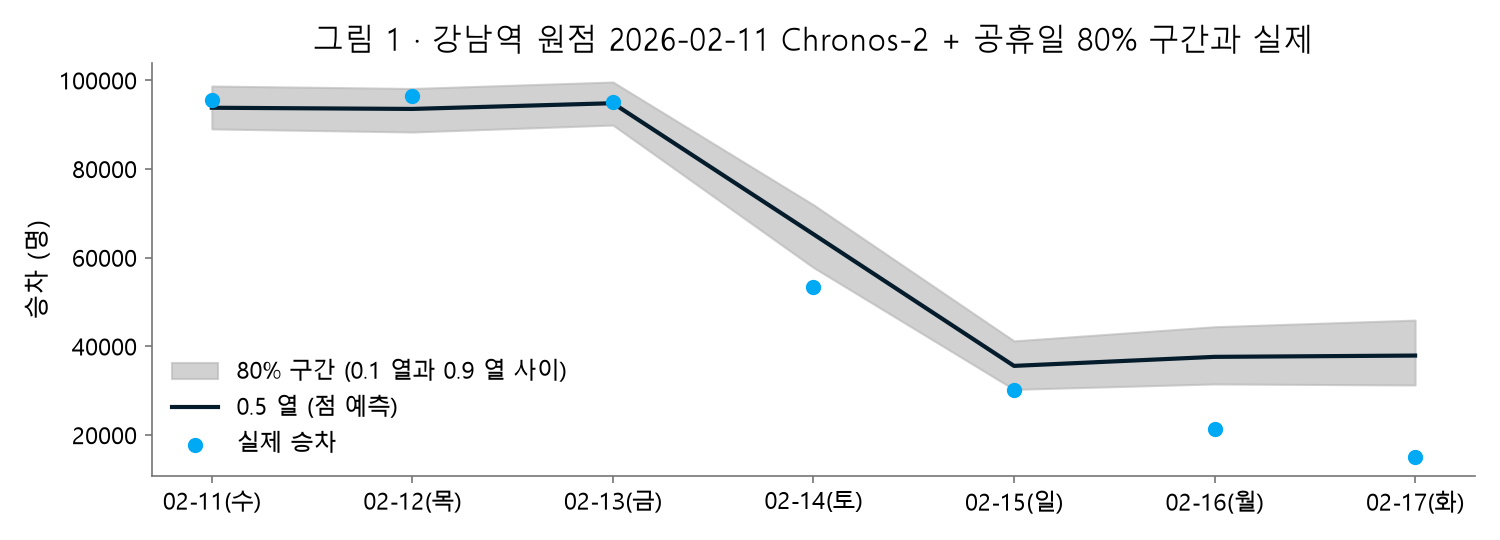

표 3 · 제로샷 80% 구간의 포함률, 공휴일이 있는 주와 없는 주 (%)
  공휴일 없는 두 주  85.1
  공휴일 있는 세 주  41.6
  원점 5개      59.0


In [3]:
# 오늘의 준비 — 읽고 실행만 합니다
#  서울 지하철 100개 역에 Chronos-2 두 모델로 원점 5개를 예측해 표 1 · 표 2 · 그림 1 · 표 3 을 만듭니다 (T4 약 20초, CPU 약 100초)
#  Chronos-2 를 불러오다 내려받기 오류(Hugging Face)가 나면 맨 위 설치 셀부터 다시 실행합니다
import os, time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

RAW_URL = "https://github.com/studio-js/seoul-subway-ridership/raw/main/data/seoul_subway_daily_2015_2026.parquet"
CACHE = "seoul_subway_daily.parquet"          # 한 번 받아 두면 다시 받지 않습니다
if not os.path.exists(CACHE):
    pd.read_parquet(RAW_URL).to_parquet(CACHE)

# 지금까지와 같은 손질 — 역 이름의 괄호 별칭을 떼고 9호선 이름을 맞춘 뒤 (날짜, 호선, 역) 으로 합칩니다
_raw = pd.read_parquet(CACHE)
_raw["date"] = pd.to_datetime(_raw["date"])
_raw["station"] = _raw["station"].astype(str).str.replace(r"\(.*\)$", "", regex=True)
_raw["line"] = _raw["line"].astype(str).replace({"9호선2단계": "9호선(2~3단계)",
                                                "9호선2~3단계": "9호선(2~3단계)"})
_clean = _raw.groupby(["date", "line", "station"], as_index=False,
                      observed=True)[["board", "alight"]].sum()
_span = _clean.groupby(["line", "station"])["date"].agg(["min", "max", "count"])
_full = _span[(_span["min"] <= pd.Timestamp("2015-01-01")) &            # 기록이 끊기지 않은 역만 남긴 뒤
              (_span["max"] >= pd.Timestamp("2026-06-30")) & (_span["count"] >= 4190)]
_top = (_clean[_clean["date"] <= pd.Timestamp("2024-12-31")]             # 2024년까지 평균 승차 상위 100개 역
        .groupby(["line", "station"])["board"].mean()
        .loc[_full.index].sort_values(ascending=False).index[:100])
_wide = _clean.pivot_table(index=["line", "station"], columns="date", values="board").loc[_top]
MAT = _wide.to_numpy(dtype=float)             # 100개 역 x 4,199일 승차 (명)
DATES = pd.DatetimeIndex(_wide.columns)       # 행렬 열의 날짜
STATIONS = [f"{_line} {_name}" for _line, _name in _wide.index]   # 행렬 행의 역 이름

H, CTX = 7, 512                               # 채점 7일 · Chronos-2 에 주는 과거 512일
QS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]   # 분위수 아홉 열 (80% 구간의 두 끝 = 0.1 열 · 0.9 열)
ORIGINS = ["2025-08-13", "2025-10-01", "2025-12-10", "2026-02-11", "2026-06-24"]   # 예측 원점 5개 (수요일)
PLAIN_ORIGINS = ["2025-12-10", "2026-06-24"]              # 공휴일 없는 두 주: 채점 7일에 평일 공휴일이 없다
HOL_ORIGINS = ["2025-08-13", "2025-10-01", "2026-02-11"]  # 공휴일 있는 세 주: 채점 7일에 평일 공휴일이 있다
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"   # 맨 위 설치 셀과 같은 규칙 — 이 셀만 실행해도 정해집니다


def hol_flags(dates):
    """날짜마다 한국 공휴일이면 1, 아니면 0 (holidays 0.103 KR, 주말 공휴일 포함) — 달력이 정하는 값입니다"""
    import holidays
    di = pd.DatetimeIndex(dates)
    kr = holidays.KR(years=sorted(set(di.year)))
    return np.array([1.0 if d in kr else 0.0 for d in di])


HOL = hol_flags(DATES)                        # DATES 의 날마다 공휴일 1 / 0


def origin_ctx(origin):
    """원점 하나의 자료 — 원점의 열 번호(o), 원점 전날까지(hist), 채점 7일 실제(test, 명), 역별 MASE 분모(qden), 채점 7일 날짜(test_dates)"""
    o = int(DATES.get_loc(pd.Timestamp(origin)))
    hist = MAT[:, :o]
    qden = np.nanmean(np.abs(hist[:, 7:] - hist[:, :-7]), axis=1)
    return dict(o=o, hist=hist, test=MAT[:, o:o + H], qden=qden, test_dates=DATES[o:o + H])


def chronos_frames(origin, holiday=True):
    """Chronos-2 의 predict_df 에 전달할 두 표 (df, future_df)

    df        : 100개 역 x 원점 전날까지 512일 — item_id(역 번호 0 ~ 99) · timestamp · target(승차, 명)
                · holiday(공휴일 1 / 0). holiday=False 면 holiday 열이 없습니다
    future_df : 100개 역 x 채점 7일 — item_id · timestamp · holiday(달력이 정한 공휴일). holiday=False 면 None
    """
    ctx = origin_ctx(origin)
    o, S = ctx["o"], MAT.shape[0]
    df = pd.DataFrame({"item_id": np.repeat(np.arange(S), CTX),
                       "timestamp": np.tile(DATES[o - CTX:o].values, S),
                       "target": MAT[:, o - CTX:o].ravel()})
    future_df = None
    if holiday:
        df["holiday"] = np.tile(HOL[o - CTX:o], S)
        future_df = pd.DataFrame({"item_id": np.repeat(np.arange(S), H),
                                  "timestamp": np.tile(ctx["test_dates"].values, S),
                                  "holiday": np.tile(HOL[o:o + H], S)})
    assert df["timestamp"].max() < pd.Timestamp(origin)   # 과거 표에는 원점 전날까지만
    return df, future_df


# Chronos-2 를 DEVICE 에 올립니다. 끊기면 세 번까지 다시 시도합니다
from chronos import BaseChronosPipeline
PIPE = None
for _try in range(1, 4):
    try:
        PIPE = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map=DEVICE, torch_dtype=torch.float32)
        break
    except Exception as _e:
        print(f"Chronos-2 불러오기 {_try}번째 실패 : {type(_e).__name__}")
        time.sleep(5)
if PIPE is None:
    raise RuntimeError("Chronos-2 를 불러오지 못했습니다. 네트워크를 확인하고 이 셀을 다시 실행합니다")

# 원점 5개 x 두 모델(제로샷 · Chronos-2 + 공휴일)의 분위수 아홉 열을 얻어 파일로 남깁니다. 미션 준비 셀이 이 파일을 읽습니다
Y_TEST = {o: origin_ctx(o)["test"] for o in ORIGINS}      # 원점 → 100개 역 x 7일 실제 승차 (명)
Q_ZS, Q_HOL = {}, {}                                       # 원점 → 100개 역 x 7일 x 분위수 아홉 열 (명)
for _holiday, _path, _store in ((False, "c2_zs_q.parquet", Q_ZS), (True, "c2_hol_q.parquet", Q_HOL)):
    _frames = []
    for o in ORIGINS:
        _df, _future = chronos_frames(o, holiday=_holiday)
        _fc = PIPE.predict_df(_df, future_df=_future, prediction_length=H, quantile_levels=QS)
        _fc = _fc.sort_values(["item_id", "timestamp"])
        _store[o] = np.stack([_fc[str(t)].to_numpy().reshape(-1, H) for t in QS], axis=-1)
        _frames.append(_fc.assign(origin=o)[["origin", "item_id", "timestamp"] + [str(t) for t in QS]])
    pd.concat(_frames, ignore_index=True).to_parquet(_path)

# 표 1: 원점마다 채점 7일에 있는 평일(월~금) 공휴일
DAY_KO = "월화수목금토일"
WDH_TABLE = {}
for o in ORIGINS:
    _c = origin_ctx(o)
    WDH_TABLE[o] = [f"{d:%m-%d}({DAY_KO[d.dayofweek]})" for d, h in zip(_c["test_dates"], HOL[_c["o"]:_c["o"] + H])
                    if h == 1 and d.dayofweek < 5]
print("표 1 · 채점 7일의 평일 공휴일 (원점 5개)")
for o in ORIGINS:
    _group = "공휴일 없는 주" if o in PLAIN_ORIGINS else "공휴일 있는 주"
    print(f"  {o} · {_group} : {' · '.join(WDH_TABLE[o]) or '없음'}")
print("  주말 공휴일 2025-10-05(일, 추석 연휴)는 평일 공휴일로 세지 않습니다")

# 표 2: 강남역, 원점 2026-06-24 의 첫 사흘. Chronos-2 + 공휴일 분위수 아홉 열과 실제 승차
GN = STATIONS.index("2호선 강남")
_d = origin_ctx("2026-06-24")["test_dates"][:3]
GN_Q = pd.DataFrame(Q_HOL["2026-06-24"][GN, :3], index=[f"{d:%Y-%m-%d}" for d in _d], columns=[str(t) for t in QS])
GN_Q["실제"] = Y_TEST["2026-06-24"][GN, :3]
print("\n표 2 · 강남역 원점 2026-06-24 Chronos-2 + 공휴일 분위수 아홉 열과 실제 (명)")
print(GN_Q.round(0).astype(int).to_string())

# 그림 1: 강남역, 원점 2026-02-11 (설 연휴가 있는 주). 0.1 열과 0.9 열 사이를 칠하고 실제 승차를 점으로
_d = origin_ctx("2026-02-11")["test_dates"]
GN_SEOL = pd.DataFrame(Q_HOL["2026-02-11"][GN][:, [0, 4, 8]], columns=["0.1", "0.5", "0.9"],
                       index=[f"{d:%m-%d}({DAY_KO[d.dayofweek]})" for d in _d])
GN_SEOL["실제"] = Y_TEST["2026-02-11"][GN]
fig, ax = plt.subplots(figsize=(10, 3.6))
_x = np.arange(H)
ax.fill_between(_x, GN_SEOL["0.1"], GN_SEOL["0.9"], color="#B3B3B3", alpha=0.6, label="80% 구간 (0.1 열과 0.9 열 사이)")
ax.plot(_x, GN_SEOL["0.5"], color="#051C2C", lw=2, label="0.5 열 (점 예측)")
ax.scatter(_x, GN_SEOL["실제"], color="#00A9F4", s=40, zorder=3, label="실제 승차")
ax.set_xticks(_x, GN_SEOL.index)
ax.set_ylabel("승차 (명)")
ax.set_title("그림 1 · 강남역 원점 2026-02-11 Chronos-2 + 공휴일 80% 구간과 실제")
ax.legend(loc="lower left", frameon=False)
plt.show()

# 표 3: 제로샷 80% 구간의 포함률을 원점마다 구해 공휴일 없는 두 주와 공휴일 있는 세 주로 평균
_cov = {o: ((Y_TEST[o] >= Q_ZS[o][..., 0]) & (Y_TEST[o] <= Q_ZS[o][..., -1])).mean() * 100 for o in ORIGINS}
COV_ZS = {"공휴일 없는 두 주": np.mean([_cov[o] for o in PLAIN_ORIGINS]),
          "공휴일 있는 세 주": np.mean([_cov[o] for o in HOL_ORIGINS]),
          "원점 5개": np.mean([_cov[o] for o in ORIGINS])}
print("표 3 · 제로샷 80% 구간의 포함률, 공휴일이 있는 주와 없는 주 (%)")
for _k, _v in COV_ZS.items():
    print(f"  {_k:<9} {_v:5.1f}")

# 0.9 열에 맞춘 인력이 모자랄 확률
예를 들어 다음 주 수요일 어느 역의 0.1 열이 8만 명, 0.9 열이 10만 명일 때 10만 명에 맞춰 인력을 두면 인력이 모자랄 확률은 얼마일까요?


A. 약 10%


약 10% 입니다. 0.9 열은 실제 승차가 그 값 이하일 확률이 90% 인 값이라, 실제가 10만 명을 넘어 인력이 모자랄 확률은 100% − 90% = 10% 이기 때문입니다(이론 「1. 분위수와 80% 구간」).

80% 구간 밖의 20% 는 두 쪽으로 나뉩니다. 0.1 열(8만 명)보다 적을 확률 10% 와 0.9 열(10만 명)보다 많을 확률 10% 입니다. 10만 명에 맞춰 인력을 두면 앞의 10% 는 인력이 남는 쪽이고, 모자라는 것은 뒤의 10% 뿐입니다.

약 20%: 80% 구간 밖의 20% 를 모두 위쪽으로 본 값입니다. 그 가운데 10% 는 0.1 열 아래라 인력이 남는 쪽입니다.
약 90%: 0.9 를 「이 값을 넘을 확률」로 거꾸로 해석한 값입니다. 90% 는 실제가 이 값 이하일 확률입니다.
그래서 이 10% 는 분위수 열이 뜻대로 맞을 때의 값입니다. 실제로 그런지는 미션 1 의 원점별 대조 행에서 위 끝보다 많은 점을 세어 확인합니다. 인력 회신에는 「0.9 열 기준, 모자랄 확률 약 10%」처럼 고른 열과 확률을 함께 적습니다.

핵심 키워드: 분위수의 뜻, 0.9 열 위로 나갈 확률, 구간 밖 20% 의 두 쪽


# 인력 계획에 전달할 80% 구간
예를 들어 같은 주에 구간 A 는 700점에서 구한 포함률이 90% 이고 평균 길이가 4,000명입니다. 구간 B 는 포함률이 80% 이고 평균 길이가 2,500명입니다. 「80% 구간」이라는 이름으로 인력 계획에 전달할 구간은 어느 쪽일까요?

B. 명목 80% 에 맞게 담으면서 구간이 짧다

B 입니다. 「80% 구간」이라는 이름으로 전달하려면 포함률이 명목 80% 에 맞아야 하는데, B 는 포함률이 80% 이면서 A 보다 1,500명 짧아 인력을 더 좁은 범위로 정해 주기 때문입니다(이론 「2. 포함률과 구간 길이」).

포함률은 구간을 길게 만들기만 해도 오르므로 평균 구간 길이와 함께 봅니다. 구간 A 는 이름이 80% 구간인데 포함률이 90% 라 90% 구간과 같습니다. 길이는 4,000 ÷ 2,500 = 1.6배이고, 4,000 − 2,500 = 1,500명 깁니다.

A. 더 많이 담았으니 더 믿을 만하다: 80% 구간이라는 이름을 받은 사람은 열 번에 두 번 벗어난다고 이해하는데, A 는 열 번에 한 번만 벗어납니다. 구간을 1.6배로 넓혀 얻은 포함률이라 인력 범위도 그만큼 넓어집니다.
어느 쪽이든 같다: 시드 범위 0.077 은 평균 MASE 에만 쓰는 기준이고, 포함률의 우연한 변동은 점의 수로 정해집니다. 구간이 정말로 80% 구간이어도 700점으로 계산한 포함률은 대개 77.0～83.0% 안에서 달라집니다(이항분포로 어림한 평균 ± 표준편차 두 배). 90% 는 이 범위보다 7.0%p 위라 우연한 변동으로 볼 수 없고, 700점 가운데 70점이 더 구간 안에 있었다는 뜻입니다. 길이 차이 1,500명도 보지 않았습니다.
그래서 모자랄 일을 더 줄이고 싶다고 구간을 넓힌 뒤 80% 구간이라 부르지는 않습니다. 대신 위쪽 열 하나를 골라 「0.9 열 기준」처럼 어느 열인지 밝혀 전달합니다. 두 구간을 비교할 때는 포함률 옆에 평균 구간 길이(명)를 함께 적습니다.

핵심 키워드: 포함률과 구간 길이, 명목 포함률, 넓혀서 오른 포함률

# 강남역 6월 25일 80% 구간 길이
「오늘의 준비」 셀을 실행하면 나오는 「표 2 · 강남역 원점 2026-06-24 Chronos-2 + 공휴일 분위수 아홉 열과 실제 (명)」을 봅니다. 2026-06-25 행의 80% 구간 길이는 약 몇 명일까요?

C. 약 5,700명

약 5,700명입니다. 80% 구간은 0.1 열과 0.9 열 사이라 길이는 0.9 열에서 0.1 열을 뺀 값이고, 표 2 의 2026-06-25 행에서 95,204 − 89,540 = 5,664명이기 때문입니다(이론 「2. 포함률과 구간 길이」).

표 2 의 출력은 명 단위로 반올림한 값이라, 손으로 빼면 5,664명이고 백 명 단위로 반올림하면 약 5,700명입니다. 이날 실제 승차 94,077명은 89,540명 이상 95,204명 이하라 구간 안에 있습니다.

약 3,600명: 0.8 열에서 0.2 열을 뺀 94,262 − 90,667 = 3,595명입니다. 0.2 열 아래 20% 와 0.8 열 위 20% 를 남긴 60% 구간의 길이입니다.
약 93,000명: 0.5 열 92,613명, 곧 점 예측이라 구간의 길이가 아닙니다.
그래서 강남역 목요일 인력을 회신할 때는 점 예측 약 92,600명 옆에 아래 끝 89,540명과 위 끝 95,204명을 함께 적어, 약 5,700명 범위 안에서 인력을 정하게 합니다.

핵심 키워드: 80% 구간의 두 끝, 구간 길이, 0.5 열은 점 예측

# 설 연휴가 있는 주 구간 밖으로 나간 날
「오늘의 준비」 셀을 실행하면 나오는 「그림 1 · 강남역 원점 2026-02-11 Chronos-2 + 공휴일 80% 구간과 실제」를 봅니다. 구간 밖으로 나간 날의 실제 승차는 구간의 어느 쪽에 있나요?

A. 모두 아래 끝보다 적었다

모두 아래 끝보다 적었습니다. 그림 1 에서 회색 구간 밖에 있는 하늘색 점 네 개(2월 14～17일)가 모두 구간 아래에 있고, 위 끝보다 많은 날은 없기 때문입니다.

구간 밖 나흘을 아래 끝과 비교합니다. 2월 14일(토)은 53,284명으로 아래 끝 57,783명보다 4,499명 적습니다. 2월 15일(일)은 30,140명으로 아래 끝 30,296명보다 156명 적어, 그림에서는 아래 끝과 거의 겹칩니다. 설 연휴 평일인 2월 16일과 17일은 21,453명·14,973명으로 아래 끝 31,522명·31,282명보다 10,069명·16,309명 적습니다. 위 끝에 가장 가까운 2월 12일(목)도 96,519명으로 위 끝 98,148명보다 1,629명 적습니다.

모두 위 끝보다 많았다: 2월 11～13일 점이 구간 위쪽에 있는 것을 위로 나간 것으로 본 것입니다. 이 사흘은 구간 안입니다.
아래와 위 양쪽으로 나갔다: 같은 오해에 아래로 나간 나흘을 더한 것입니다. 위로 나간 날은 없습니다.
그래서 Chronos-2 + 공휴일은 연휴 날의 승차를 평일보다 크게 낮춰 예측했지만, 실제는 그보다 더 적었습니다. 2월 14·15일은 설 연휴 앞 주말인데 holiday 열이 0 이라 평소 주말처럼 예측해, 이 이틀도 아래 끝보다 적었습니다. 평일 공휴일 당일 인력은 구간으로 정하지 않고 따로 정합니다(이론 「2. 포함률과 구간 길이」와 「3. 서울 지하철 100개 역의 포함률」).

설 연휴 평일 이틀의 점 예측은 공변량을 배울 때 정한 규칙대로 따로 정합니다. 1주 전 같은 요일 승차에 지난해 설날 전날·설날의 비를 곱합니다. 이 비는 그날 승차를 앞뒤 2주의 공휴일 아닌 같은 요일 평균으로 나눈 값이고, 강남역은 0.218배·0.142배였습니다. 나머지 평일 공휴일 당일 인력은 임계비율을 배울 때 정합니다.

핵심 키워드: 구간 밖으로 나간 방향, 설 연휴, 평일 공휴일 당일

# 제로샷 구간을 평일 공휴일이 있는 주 인력에
「오늘의 준비」 셀을 실행하면 나오는 「표 3 · 제로샷 80% 구간의 포함률, 공휴일이 있는 주와 없는 주 (%)」을 봅니다. 평일 공휴일이 있는 주의 인력 계획에 제로샷 80% 구간을 넘겨도 될까요?

B. 넘기지 않는다. 공휴일 있는 세 주에서 절반도 담지 못했다

넘기지 않습니다. 평일 공휴일이 있는 주에 쓸지는 표 3 의 공휴일 있는 세 주 값으로 정하는데, 그 값 41.6% 는 공휴일 있는 세 주 2,100점 가운데 구간 안이 873점뿐이라 절반에도 못 미치고, 명목 80% 보다 80 − 41.6 = 38.4%p 낮기 때문입니다(이론 「2. 포함률과 구간 길이」).

표 3 의 세 값은 공휴일 없는 두 주 85.1%, 공휴일 있는 세 주 41.6%, 원점 5개 59.0% 입니다. 원점 5개 값은 3,500점을 합쳐 구한 값이라 (2 × 85.1 + 3 × 41.6) ÷ 5 = 295.0 ÷ 5 = 59.0% 로, 두 주와 세 주의 값을 원점 수로 가중 평균한 값과 같습니다.

넘긴다. 공휴일 없는 두 주에서 80% 를 넘게 담았다: 85.1% 는 평일 공휴일이 없는 주의 값이라, 평일 공휴일이 있는 주를 판단할 근거가 아닙니다.
넘긴다. 원점 5개를 합치면 명목 80% 에 가깝다: 59.0% 도 80% 보다 21.0%p 낮아 가깝지 않습니다. 평균 하나로 보면 공휴일 있는 세 주의 41.6% 가 드러나지 않습니다.
그래서 제로샷 구간은 평일 공휴일이 있는 주의 인력 계획에 전달하지 않습니다. 전달할 구간은 쓸 수 있는 구간끼리 비교해 정하므로, 공휴일 열을 입력한 Chronos-2 + 공휴일에서 이 41.6% 가 얼마나 높아지는지 미션 1 에서 구합니다.

핵심 키워드: 공휴일 유무로 나눈 포함률, 명목 80% 와의 비교, 평균 하나만 보는 실수

In [4]:
# 미션 1 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 1 에 쓸 이름을 직접 만듭니다
#  「오늘의 준비」 셀이 남긴 분위수 파일을 읽고, 파일이 없으면 Chronos-2 로 다시 예측합니다 (T4 약 10초)
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

RAW_URL = "https://github.com/studio-js/seoul-subway-ridership/raw/main/data/seoul_subway_daily_2015_2026.parquet"
CACHE = "seoul_subway_daily.parquet"          # 한 번 받아 두면 다시 받지 않습니다
if not os.path.exists(CACHE):
    pd.read_parquet(RAW_URL).to_parquet(CACHE)

# 지금까지와 같은 손질 — 역 이름의 괄호 별칭을 떼고 9호선 이름을 맞춘 뒤 (날짜, 호선, 역) 으로 합칩니다
_raw = pd.read_parquet(CACHE)
_raw["date"] = pd.to_datetime(_raw["date"])
_raw["station"] = _raw["station"].astype(str).str.replace(r"\(.*\)$", "", regex=True)
_raw["line"] = _raw["line"].astype(str).replace({"9호선2단계": "9호선(2~3단계)",
                                                "9호선2~3단계": "9호선(2~3단계)"})
_clean = _raw.groupby(["date", "line", "station"], as_index=False,
                      observed=True)[["board", "alight"]].sum()
_span = _clean.groupby(["line", "station"])["date"].agg(["min", "max", "count"])
_full = _span[(_span["min"] <= pd.Timestamp("2015-01-01")) &            # 기록이 끊기지 않은 역만 남긴 뒤
              (_span["max"] >= pd.Timestamp("2026-06-30")) & (_span["count"] >= 4190)]
_top = (_clean[_clean["date"] <= pd.Timestamp("2024-12-31")]             # 2024년까지 평균 승차 상위 100개 역
        .groupby(["line", "station"])["board"].mean()
        .loc[_full.index].sort_values(ascending=False).index[:100])
_wide = _clean.pivot_table(index=["line", "station"], columns="date", values="board").loc[_top]
MAT = _wide.to_numpy(dtype=float)             # 100개 역 x 4,199일 승차 (명)
DATES = pd.DatetimeIndex(_wide.columns)       # 행렬 열의 날짜
STATIONS = [f"{_line} {_name}" for _line, _name in _wide.index]   # 행렬 행의 역 이름

H, CTX = 7, 512                               # 채점 7일 · Chronos-2 에 주는 과거 512일
QS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]   # 분위수 아홉 열 (80% 구간의 두 끝 = 0.1 열 · 0.9 열)
ORIGINS = ["2025-08-13", "2025-10-01", "2025-12-10", "2026-02-11", "2026-06-24"]   # 예측 원점 5개 (수요일)
PLAIN_ORIGINS = ["2025-12-10", "2026-06-24"]              # 공휴일 없는 두 주: 채점 7일에 평일 공휴일이 없다
HOL_ORIGINS = ["2025-08-13", "2025-10-01", "2026-02-11"]  # 공휴일 있는 세 주: 채점 7일에 평일 공휴일이 있다
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"   # 맨 위 설치 셀과 같은 규칙 — 이 셀만 실행해도 정해집니다


def hol_flags(dates):
    """날짜마다 한국 공휴일이면 1, 아니면 0 (holidays 0.103 KR, 주말 공휴일 포함) — 달력이 정하는 값입니다"""
    import holidays
    di = pd.DatetimeIndex(dates)
    kr = holidays.KR(years=sorted(set(di.year)))
    return np.array([1.0 if d in kr else 0.0 for d in di])


HOL = hol_flags(DATES)                        # DATES 의 날마다 공휴일 1 / 0


def origin_ctx(origin):
    """원점 하나의 자료 — 원점의 열 번호(o), 원점 전날까지(hist), 채점 7일 실제(test, 명), 역별 MASE 분모(qden), 채점 7일 날짜(test_dates)"""
    o = int(DATES.get_loc(pd.Timestamp(origin)))
    hist = MAT[:, :o]
    qden = np.nanmean(np.abs(hist[:, 7:] - hist[:, :-7]), axis=1)
    return dict(o=o, hist=hist, test=MAT[:, o:o + H], qden=qden, test_dates=DATES[o:o + H])


def chronos_frames(origin, holiday=True):
    """Chronos-2 의 predict_df 에 전달할 두 표 (df, future_df)

    df        : 100개 역 x 원점 전날까지 512일 — item_id(역 번호 0 ~ 99) · timestamp · target(승차, 명)
                · holiday(공휴일 1 / 0). holiday=False 면 holiday 열이 없습니다
    future_df : 100개 역 x 채점 7일 — item_id · timestamp · holiday(달력이 정한 공휴일). holiday=False 면 None
    """
    ctx = origin_ctx(origin)
    o, S = ctx["o"], MAT.shape[0]
    df = pd.DataFrame({"item_id": np.repeat(np.arange(S), CTX),
                       "timestamp": np.tile(DATES[o - CTX:o].values, S),
                       "target": MAT[:, o - CTX:o].ravel()})
    future_df = None
    if holiday:
        df["holiday"] = np.tile(HOL[o - CTX:o], S)
        future_df = pd.DataFrame({"item_id": np.repeat(np.arange(S), H),
                                  "timestamp": np.tile(ctx["test_dates"].values, S),
                                  "holiday": np.tile(HOL[o:o + H], S)})
    assert df["timestamp"].max() < pd.Timestamp(origin)   # 과거 표에는 원점 전날까지만
    return df, future_df


def load_quantiles(path, holiday):
    """분위수 파일(origin · item_id · timestamp · "0.1"~"0.9")을 원점 → 100 x 7 x 9 배열로 읽습니다.
    「오늘의 준비」 셀이 남긴 파일이 없으면 Chronos-2 로 원점 5개를 예측해 그 파일을 만듭니다"""
    if not os.path.exists(path):
        from chronos import BaseChronosPipeline
        pipe = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map=DEVICE, torch_dtype=torch.float32)
        frames = []
        for o in ORIGINS:
            df, future_df = chronos_frames(o, holiday=holiday)
            fc = pipe.predict_df(df, future_df=future_df, prediction_length=H, quantile_levels=QS)
            frames.append(fc.assign(origin=o)[["origin", "item_id", "timestamp"] + [str(t) for t in QS]])
        pd.concat(frames, ignore_index=True).to_parquet(path)
    d = pd.read_parquet(path).sort_values(["origin", "item_id", "timestamp"])
    return {o: np.stack([g[str(t)].to_numpy().reshape(-1, H) for t in QS], axis=-1)
            for o, g in d.groupby("origin")}


Y_TEST = {o: origin_ctx(o)["test"] for o in ORIGINS}       # 원점 → 100개 역 x 7일 실제 승차 (명)
Q_HOL = load_quantiles("c2_hol_q.parquet", holiday=True)   # 원점 → Chronos-2 + 공휴일 100개 역 x 7일 x 9열 (명)

print(f"자료 : 100개 역 x {MAT.shape[1]:,}일 승차 · 원점 5개 = 공휴일 없는 두 주 {' · '.join(PLAIN_ORIGINS)}"
      f" + 공휴일 있는 세 주 {' · '.join(HOL_ORIGINS)}")
print(f"Q_HOL : 원점마다 {Q_HOL[ORIGINS[0]].shape} (100개 역 x 7일 x 분위수 아홉 열, 명) · "
      f"Y_TEST : 원점마다 {Y_TEST[ORIGINS[0]].shape} (100개 역 x 7일, 명)")
print("쓸 수 있는 이름 : Q_HOL · Y_TEST · ORIGINS · PLAIN_ORIGINS · HOL_ORIGINS · QS (설치 셀의 COL · FIG_W 도 씁니다)")

자료 : 100개 역 x 4,199일 승차 · 원점 5개 = 공휴일 없는 두 주 2025-12-10 · 2026-06-24 + 공휴일 있는 세 주 2025-08-13 · 2025-10-01 · 2026-02-11
Q_HOL : 원점마다 (100, 7, 9) (100개 역 x 7일 x 분위수 아홉 열, 명) · Y_TEST : 원점마다 (100, 7) (100개 역 x 7일, 명)
쓸 수 있는 이름 : Q_HOL · Y_TEST · ORIGINS · PLAIN_ORIGINS · HOL_ORIGINS · QS (설치 셀의 COL · FIG_W 도 씁니다)


공휴일 없는 두 주 포함률: 79.5%
공휴일 있는 세 주 포함률: 66.4%
2025-08-13  구간 안 552  아래 120  위 28  (합 700)
2025-10-01  구간 안 430  아래 142  위 128  (합 700)
2025-12-10  구간 안 559  아래 13  위 128  (합 700)
2026-02-11  구간 안 413  아래 262  위 25  (합 700)
2026-06-24  구간 안 554  아래 9  위 137  (합 700)


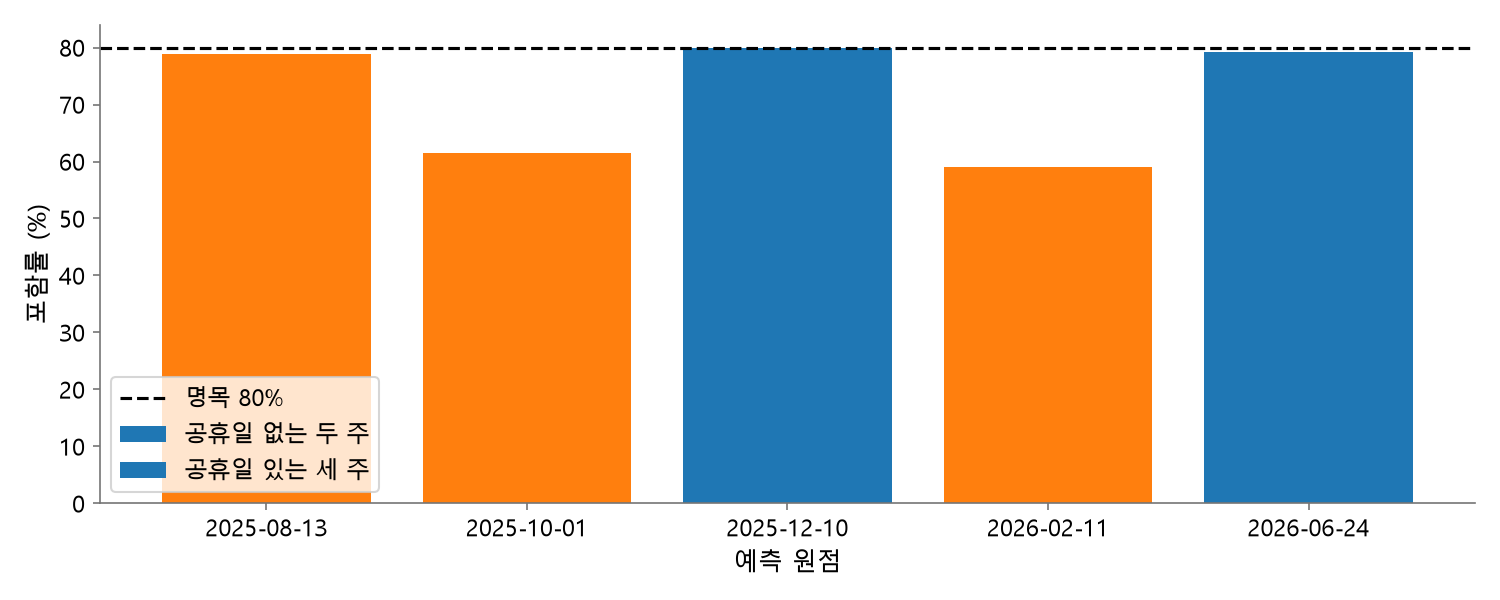

In [5]:
# 미션 1 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → AI 튜터에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
# 시킬 일은 AI 튜터 대화창이 아니라 아래 따옴표 안에 적습니다. 예시 프롬프트도 따옴표 안에 붙여 넣어야 채점됩니다
PROMPT = """
Chronos-2 + 공휴일의 80% 구간은 공휴일 없는 두 주와 공휴일 있는 세 주에서 포함률이 각각 몇 % 일까요?를 주제로 아래 출력물을 만들어야해
미션 1 준비셀에서 만들어둔 변수는 코드 작성 시 새로 만들지말고 그대로 사용해
1. 공휴일 없는 두 주 포함률: 단위 %, 소수 첫째 자리, 원점마다 700점 가운데 실제가 0.1열 이상 0.9열 이하인 점의 비율을 구해 PLAIN_ORIGINS 두 원점으로 평균함.
2. 공휴일 있는 세 주 포함률: 단위 %, 소수 첫째 자리, 1번과 같은 방법 단 HOL_ORIGINS 세 원점을 기준으로 평균함.
3. 원점별 대조 행: 원점마다 구간 안, 아래, 위 점 수를 한 행씩 찍음(별도의 행)
4. 그래프
가로: 예측 원점
세로: 포함률 (%)
원점 5개 포함률 막대, 두 주, 세 주를 다른 색으로 80% 높이에 가로 점선 추가

"""
# --- 여기부터 AI 코드 ---
import numpy as np
import matplotlib.pyplot as plt

stats = {}
for o in ORIGINS:
    q = np.asarray(Q_HOL[o])
    y = np.asarray(Y_TEST[o])
    lo, hi = q[..., 0], q[..., -1]
    below = int((y < lo).sum())
    above = int((y > hi).sum())
    inside = int(y.size - below - above)
    stats[o] = (inside, below, above, inside / y.size * 100)

def cover(origins):
    return float(np.mean([stats[o][3] for o in origins]))

print(f"공휴일 없는 두 주 포함률: {cover(PLAIN_ORIGINS):.1f}%")
print(f"공휴일 있는 세 주 포함률: {cover(HOL_ORIGINS):.1f}%")

for o in ORIGINS:
    inside, below, above, rate = stats[o]
    print(f"{o}  구간 안 {inside}  아래 {below}  위 {above}  (합 {inside + below + above})")

c_plain, c_hol = "tab:blue", "tab:orange"
colors = [c_plain if o in PLAIN_ORIGINS else c_hol for o in ORIGINS]

plt.figure(figsize=(FIGW, 4))
plt.bar(ORIGINS, [stats[o][3] for o in ORIGINS], color=colors)
plt.axhline(80, color="black", linestyle="--", label="명목 80%")
plt.xlabel("예측 원점")
plt.ylabel("포함률 (%)")
plt.bar([], [], color=c_plain, label="공휴일 없는 두 주")
plt.bar([], [], color=c_hol, label="공휴일 있는 세 주")
plt.legend()
plt.show()

In [6]:
# 미션 2 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 2 에 쓸 이름을 직접 만듭니다
#  「오늘의 준비」 셀이 남긴 두 모델의 분위수 파일을 읽고, 파일이 없으면 Chronos-2 로 다시 예측합니다 (T4 약 20초)
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

RAW_URL = "https://github.com/studio-js/seoul-subway-ridership/raw/main/data/seoul_subway_daily_2015_2026.parquet"
CACHE = "seoul_subway_daily.parquet"          # 한 번 받아 두면 다시 받지 않습니다
if not os.path.exists(CACHE):
    pd.read_parquet(RAW_URL).to_parquet(CACHE)

# 지금까지와 같은 손질 — 역 이름의 괄호 별칭을 떼고 9호선 이름을 맞춘 뒤 (날짜, 호선, 역) 으로 합칩니다
_raw = pd.read_parquet(CACHE)
_raw["date"] = pd.to_datetime(_raw["date"])
_raw["station"] = _raw["station"].astype(str).str.replace(r"\(.*\)$", "", regex=True)
_raw["line"] = _raw["line"].astype(str).replace({"9호선2단계": "9호선(2~3단계)",
                                                "9호선2~3단계": "9호선(2~3단계)"})
_clean = _raw.groupby(["date", "line", "station"], as_index=False,
                      observed=True)[["board", "alight"]].sum()
_span = _clean.groupby(["line", "station"])["date"].agg(["min", "max", "count"])
_full = _span[(_span["min"] <= pd.Timestamp("2015-01-01")) &            # 기록이 끊기지 않은 역만 남긴 뒤
              (_span["max"] >= pd.Timestamp("2026-06-30")) & (_span["count"] >= 4190)]
_top = (_clean[_clean["date"] <= pd.Timestamp("2024-12-31")]             # 2024년까지 평균 승차 상위 100개 역
        .groupby(["line", "station"])["board"].mean()
        .loc[_full.index].sort_values(ascending=False).index[:100])
_wide = _clean.pivot_table(index=["line", "station"], columns="date", values="board").loc[_top]
MAT = _wide.to_numpy(dtype=float)             # 100개 역 x 4,199일 승차 (명)
DATES = pd.DatetimeIndex(_wide.columns)       # 행렬 열의 날짜
STATIONS = [f"{_line} {_name}" for _line, _name in _wide.index]   # 행렬 행의 역 이름

H, CTX = 7, 512                               # 채점 7일 · Chronos-2 에 주는 과거 512일
QS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]   # 분위수 아홉 열 (80% 구간의 두 끝 = 0.1 열 · 0.9 열)
ORIGINS = ["2025-08-13", "2025-10-01", "2025-12-10", "2026-02-11", "2026-06-24"]   # 예측 원점 5개 (수요일)
PLAIN_ORIGINS = ["2025-12-10", "2026-06-24"]              # 공휴일 없는 두 주: 채점 7일에 평일 공휴일이 없다
HOL_ORIGINS = ["2025-08-13", "2025-10-01", "2026-02-11"]  # 공휴일 있는 세 주: 채점 7일에 평일 공휴일이 있다
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"   # 맨 위 설치 셀과 같은 규칙 — 이 셀만 실행해도 정해집니다


def hol_flags(dates):
    """날짜마다 한국 공휴일이면 1, 아니면 0 (holidays 0.103 KR, 주말 공휴일 포함) — 달력이 정하는 값입니다"""
    import holidays
    di = pd.DatetimeIndex(dates)
    kr = holidays.KR(years=sorted(set(di.year)))
    return np.array([1.0 if d in kr else 0.0 for d in di])


HOL = hol_flags(DATES)                        # DATES 의 날마다 공휴일 1 / 0


def origin_ctx(origin):
    """원점 하나의 자료 — 원점의 열 번호(o), 원점 전날까지(hist), 채점 7일 실제(test, 명), 역별 MASE 분모(qden), 채점 7일 날짜(test_dates)"""
    o = int(DATES.get_loc(pd.Timestamp(origin)))
    hist = MAT[:, :o]
    qden = np.nanmean(np.abs(hist[:, 7:] - hist[:, :-7]), axis=1)
    return dict(o=o, hist=hist, test=MAT[:, o:o + H], qden=qden, test_dates=DATES[o:o + H])


def chronos_frames(origin, holiday=True):
    """Chronos-2 의 predict_df 에 전달할 두 표 (df, future_df)

    df        : 100개 역 x 원점 전날까지 512일 — item_id(역 번호 0 ~ 99) · timestamp · target(승차, 명)
                · holiday(공휴일 1 / 0). holiday=False 면 holiday 열이 없습니다
    future_df : 100개 역 x 채점 7일 — item_id · timestamp · holiday(달력이 정한 공휴일). holiday=False 면 None
    """
    ctx = origin_ctx(origin)
    o, S = ctx["o"], MAT.shape[0]
    df = pd.DataFrame({"item_id": np.repeat(np.arange(S), CTX),
                       "timestamp": np.tile(DATES[o - CTX:o].values, S),
                       "target": MAT[:, o - CTX:o].ravel()})
    future_df = None
    if holiday:
        df["holiday"] = np.tile(HOL[o - CTX:o], S)
        future_df = pd.DataFrame({"item_id": np.repeat(np.arange(S), H),
                                  "timestamp": np.tile(ctx["test_dates"].values, S),
                                  "holiday": np.tile(HOL[o:o + H], S)})
    assert df["timestamp"].max() < pd.Timestamp(origin)   # 과거 표에는 원점 전날까지만
    return df, future_df


def load_quantiles(path, holiday):
    """분위수 파일(origin · item_id · timestamp · "0.1"~"0.9")을 원점 → 100 x 7 x 9 배열로 읽습니다.
    「오늘의 준비」 셀이 남긴 파일이 없으면 Chronos-2 로 원점 5개를 예측해 그 파일을 만듭니다"""
    if not os.path.exists(path):
        from chronos import BaseChronosPipeline
        pipe = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map=DEVICE, torch_dtype=torch.float32)
        frames = []
        for o in ORIGINS:
            df, future_df = chronos_frames(o, holiday=holiday)
            fc = pipe.predict_df(df, future_df=future_df, prediction_length=H, quantile_levels=QS)
            frames.append(fc.assign(origin=o)[["origin", "item_id", "timestamp"] + [str(t) for t in QS]])
        pd.concat(frames, ignore_index=True).to_parquet(path)
    d = pd.read_parquet(path).sort_values(["origin", "item_id", "timestamp"])
    return {o: np.stack([g[str(t)].to_numpy().reshape(-1, H) for t in QS], axis=-1)
            for o, g in d.groupby("origin")}


Y_TEST = {o: origin_ctx(o)["test"] for o in ORIGINS}       # 원점 → 100개 역 x 7일 실제 승차 (명)
Q_ZS = load_quantiles("c2_zs_q.parquet", holiday=False)    # 원점 → 제로샷 100개 역 x 7일 x 9열 (명)
Q_HOL = load_quantiles("c2_hol_q.parquet", holiday=True)   # 원점 → Chronos-2 + 공휴일 100개 역 x 7일 x 9열 (명)

print(f"자료 : 100개 역 x {MAT.shape[1]:,}일 승차 · 원점 5개 = 공휴일 없는 두 주 {' · '.join(PLAIN_ORIGINS)}"
      f" + 공휴일 있는 세 주 {' · '.join(HOL_ORIGINS)}")
print(f"Q_ZS · Q_HOL : 원점마다 {Q_HOL[ORIGINS[0]].shape} (100개 역 x 7일 x 분위수 아홉 열, 명) · "
      f"Y_TEST : 원점마다 {Y_TEST[ORIGINS[0]].shape} (100개 역 x 7일, 명)")
print("쓸 수 있는 이름 : Q_ZS · Q_HOL · Y_TEST · ORIGINS · PLAIN_ORIGINS · HOL_ORIGINS · QS (설치 셀의 COL · FIG_W 도 씁니다)")

자료 : 100개 역 x 4,199일 승차 · 원점 5개 = 공휴일 없는 두 주 2025-12-10 · 2026-06-24 + 공휴일 있는 세 주 2025-08-13 · 2025-10-01 · 2026-02-11
Q_ZS · Q_HOL : 원점마다 (100, 7, 9) (100개 역 x 7일 x 분위수 아홉 열, 명) · Y_TEST : 원점마다 (100, 7) (100개 역 x 7일, 명)
쓸 수 있는 이름 : Q_ZS · Q_HOL · Y_TEST · ORIGINS · PLAIN_ORIGINS · HOL_ORIGINS · QS (설치 셀의 COL · FIG_W 도 씁니다)


Chronos-2 + 공휴일의 공휴일 있는 세 주 평균 구간 길이 = 5734명
공휴일 있는 세 주 구간 길이 비 = 1.52배


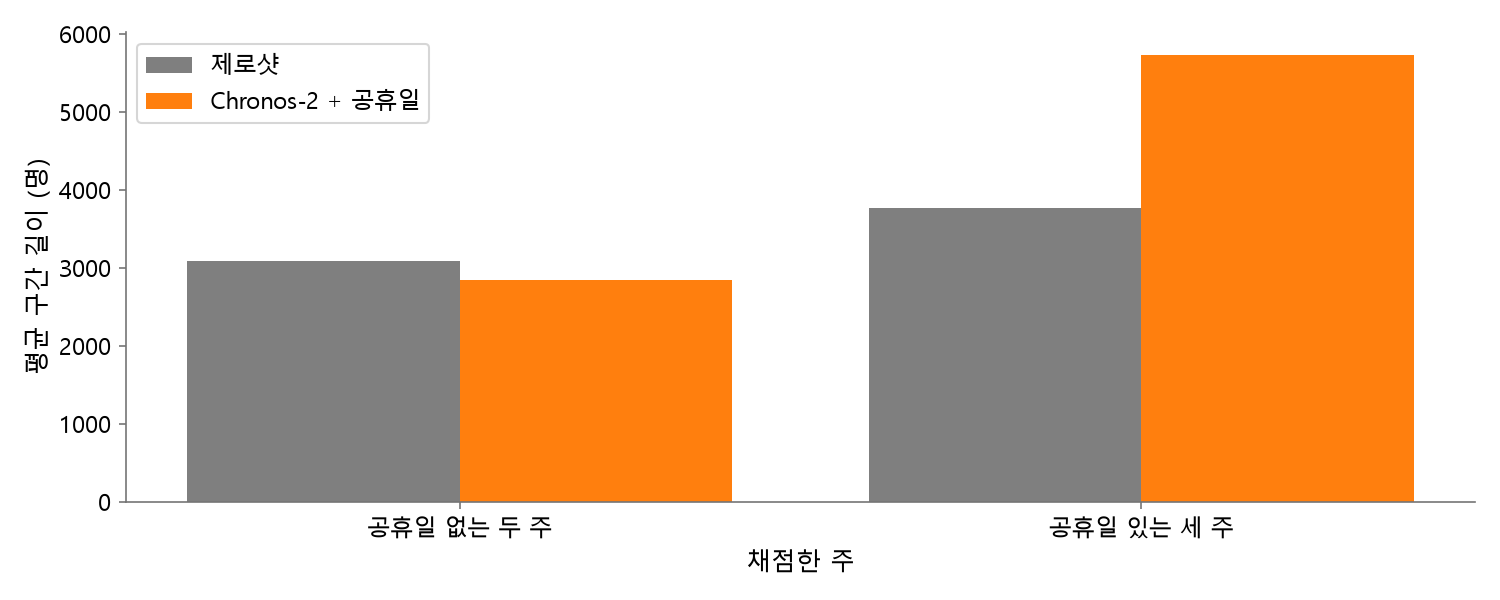

In [7]:
# 미션 2 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → AI 튜터에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
# 시킬 일은 AI 튜터 대화창이 아니라 아래 따옴표 안에 적습니다. 따옴표 안이 비어 있으면 채점과 완성본 풀이가 잠깁니다
PROMPT = """
Chronos-2 + 공휴일의 공휴일 있는 세 주 포함률이 제로샷보다 높은 것은 구간을 넓혀서일까요? 라는 질문으로 출력물을 만들거야
미션 2 준비 셀이 만들어둔 이름 즉 본문의 변수들은 새로 만들지말고 변경하지 말고 그대로 사용해줘
1. Chronos-2 + 공휴일의 공휴일 있는 세 주 평균 구간 길이: 단위 명, 정수, 구간 길이는 역, 날마다 0.9열에서 0.1열을 뺀 값
원점마다 700점으로 평균한 뒤 HOL_ORIGINS 세 원점을 평균함, 천명으로 나누지 않고 명 단위 그대로 적음

2. 공휴일 있는 세 주 구간 길이 비: 단위 배, 소수 둘째 자리, 공휴일 있는 세 주에서 Chronos-2 + 공휴일의 평균 구간 길이를 제로샷의 값으로 나눔
3. 그래프
가로: 채점한 주
세로: 평균 구간 길이(명)
공휴일 유무 x 두 모델의 막대 4개에 범례 두 모델임
"""
# --- 여기부터 AI 코드 ---
import numpy as np
import matplotlib.pyplot as plt

def mean_width(Q, origins):
    per_origin = []
    for o in origins:
        q = np.asarray(Q[o])
        per_origin.append(np.mean(q[..., -1] - q[..., 0]))
    return float(np.mean(per_origin))

w_hol = {"제로샷": mean_width(Q_ZS, HOL_ORIGINS),
         "Chronos-2 + 공휴일": mean_width(Q_HOL, HOL_ORIGINS)}
w_plain = {"제로샷": mean_width(Q_ZS, PLAIN_ORIGINS),
           "Chronos-2 + 공휴일": mean_width(Q_HOL, PLAIN_ORIGINS)}

ratio = w_hol["Chronos-2 + 공휴일"] / w_hol["제로샷"]

print(f"Chronos-2 + 공휴일의 공휴일 있는 세 주 평균 구간 길이 = {w_hol['Chronos-2 + 공휴일']:.0f}명")
print(f"공휴일 있는 세 주 구간 길이 비 = {ratio:.2f}배")

groups = ["공휴일 없는 두 주", "공휴일 있는 세 주"]
zs = [w_plain["제로샷"], w_hol["제로샷"]]
ch = [w_plain["Chronos-2 + 공휴일"], w_hol["Chronos-2 + 공휴일"]]
x = np.arange(len(groups))

plt.figure(figsize=(FIGW, 4))
plt.bar(x - 0.2, zs, width=0.4, color="tab:gray", label="제로샷")
plt.bar(x + 0.2, ch, width=0.4, color="tab:orange", label="Chronos-2 + 공휴일")
plt.xticks(x, groups)
plt.xlabel("채점한 주")
plt.ylabel("평균 구간 길이 (명)")
plt.legend()
plt.show()